# Laboratorio 7
## Aprendizaje por refuerzo

Francis Aguilar, 22243

Jose Marchena, 22398

Cesar Lopez, 22535

# Repositorio

https://github.com/MarchMol/lab7_rl

## Instrucciones
Una empresa de ciberseguridad opera un sistema de detección de intrusiones en redes corporativas. El sistema monitorea el tráfico de red en tiempo real y debe decidir qué acciones tomar ante comportamientos sospechosos: **ignorar, alertar, bloquear temporalmente o aislar el segmento afectado**.

El estado del sistema en cada instante es un vector de alta dimensión que incluye métricas de tráfico, patrones de comportamiento de usuarios y logs de eventos recientes. La empresa quiere explorar si **Deep RL** puede mejorar la toma de decisiones frente a los sistemas basados en reglas que usan actualmente.


# Task 1 (Entrega Parcial)

## Task 1.1

El equipo de ingeniería propone usar **DQN estándar** para este sistema. Antes de implementar cualquier cosa, usted debe hacer un análisis crítico de esa propuesta.

### a.

El estado del sistema es un vector de **256 dimensiones con valores continuos**.

Argumenten si DQN es arquitecturalmente apropiado para este tipo de estado.

> DQN si puede ser apropiado para este tipo de estado, dado que es agnostico al modelo de aprendizaje profundo que se integre. Es decir, cuando se usa para videojuegos como el caso de Atari ellos utilizaron una red convolucional sobre el input de pixeles. En nuestro caso, una red convolucional talvez no sea tan util, pero definitivamente un vector de entrada de 256 dimensiones es apropiado. Asimismo, las redes neuronales por detras manejan muy bien valores continuos y en todo caso, es una de las razones principales por las cuales utilizar DQN en lugar de otros tipos de agentes que estan limitados a espacios discrectos.
¿Qué tipo de red usarían como aproximador de $Q(s,a;\mathbf{w})$ y por qué, considerando que el estado no es una imagen sino un vector numérico?
> Lo mas sencillo y justificable es utilizar una red completamente conectada. Esta nos permite encontrar relaciones entre las diferentes features numericas y concentrar el resultado en un solo valor ya sea con un softmax o algo por el estilo. 

### b.

El espacio de acciones tiene **4 opciones discretas**.

Argumenten si DQN o alguna de sus variantes es apropiado para este espacio de acciones, o si sería necesario un algoritmo diferente.

El espacio de 4 opciones discretas es apropiado e incluso ideal para todos los casos de DQN.

### c.

En el dominio de detección de intrusiones, los eventos críticos (**intrusiones reales**) son extremadamente raros: ocurren en menos del **0.1% de los pasos de tiempo**.

Argumenten formalmente qué consecuencia tiene esa rareza sobre el buffer de **Experience Replay** y sobre la distribución de muestreo uniforme.

¿Qué variante de DQN resolvería este problema específico y cómo?

>DQN estandar talvez no sea ideal para nuestro caso de uso dado sus problemas con estbilidad, sobreestimación e ineficancia del sampling. Se recomienda utilizar una variante ya sea Double DQN o Dueling DQN, pues nos permiten sobrepasar varias limitaciones y Dueling funciona bien para nuestro caso de uso, donde varias acciones pueden llevar a un futuro idéntico, que es el caso donde los eventos criticos son raros. 

### d.

El sistema actual basado en reglas tiene una tasa de falsos positivos del **8%**.

Si diseñaran la función de recompensa de DQN para minimizar falsos positivos únicamente, ¿qué comportamiento indeseable podría aprender el agente?
> Si se busca minimizar falsos positivos, es posible que el modelo pueda llegar a un overfitting donde casi nunca marca como crítico a una conexión, dejando de lado todo su objetivo de identificar correctamente estas conexiones maliciosas.

Diseñen una función de recompensa con **al menos tres componentes** que capture el objetivo real del sistema, justificando la magnitud relativa de cada uno.

>Aunque se desconoce la naturaleza o significado especifico de las features como para armar una funcion de recompenza basado en el valor especifico del estado, se puede abordar la funcion de recompenza sobre las acciones y la retroalimentacion entre estados. Por tanto se proponen los siguientes 3 mecanismos principales para la recompenza:

1. Accuracy: da recompenza a las identificaciones de conexión critica. Sin esta, el modelo nunca buscaria identificar correctamente, pero no elimina la posibilidad de falsos positivios.
- Regularizacion: mecanismos agresivos de regularizacion para para penalizar acciones demasiado defensivas, esto deberia disminuir la cantidad de falsos positivs.
- Penalizacion por accion: no todas las acciones son iguales en terminos de el efecto que tienen sobre la usabilidad, entonces debe de haber un descuento sobre la friccion introducida por cada accion. Las acciones de ignorar o alertar deben de tener una baja o nula penalizacion, pero acciones fuertes como bloquear temporalmente o aislar deben tener una penalizacion representativa.

Con respecto a la magnitu relativa de cada una, se propone la siguiente magnitud relativa
Accuracy > Friccion por accion > regularizacion
La identificacion positiva debe de ser el componente de mayor influencia pues es la que mueve las acciones del modelo. Luego las fricciones por accion siguen pues acciones muy agresivas como aislamiento o bloqueo temporal tienen efectos cruciales en la usabilidad de la plataforma. Por ultimo la regularizacion para alizar la continuidad de falsos positivos.

---

## Task 1.2

El equipo propone usar **Double DQN** en lugar de DQN estándar.

### a.

Expliquen formalmente el problema de **sobreestimación** que Double DQN resuelve.

El problema de sobreestimación origina de la función de target que utilizan estos agentes para calcular el valor de un accion
$TARGET = R + \gamma max Q(s',a)$
La toma a partir del valor de retorno máximo asociado a cada uno. Dado que los algoritmos detras de DQN tienden a poseer ruido, escoger siempre el máximos sistematicamente elige los picos del ruido presente en sus predicciones, es decir, tiende a sobreestimar el retorno esperado de cada accion.

Double DQN resuelve esto a partir de su abordaje con dos modelos, el Online y el Target. Esta separación busca diferenciar la evaluación entre el valor aparente de una accion actualmente (la red online) vs el valor actual de la accion (la red Target). Es decir mientras que la red online toma la decision es susceptible al ruido, la red target lo evalua de manera mas precisa y esto tiene el efecto de cancelar la sobreestimación.

En el contexto específico de detección de intrusiones:

- ¿Qué consecuencia operacional tendría que el agente sobreestime sistemáticamente el valor de la acción `"bloquear"`?

> Si el agente sobreestima sistematicamente BLOQUEAR, significa que ve el posible retorno de bloquear una conexión critica y tendrá a escogerlo más frecuentemente frente a comportamientos extraños. Sin embargo, esto es exactamente lo que causa una alta tasa de falsos positivos e introduce alta fricción en comportamiento normal de usuarios al bloquear mas de los que necesita o puede detectar con certeza.

- ¿Y de la acción `"ignorar"`?
> Asimismo, si muestra un sesgo sobre IGNORAR va a tender a ejecutar esta acción más frecuentemente dependiendo de la ponderación de retorno. Esto puede tener exactamente el efecto opuesto al anterior: al ver que le da más retorno ignorar tráfico, puede llegar a obviar entrads que si muestren patrones críticos y corre el riesgo de no identificar correctamente estos escenarios.

### b.

Escriban la expresión del **target de DQN estándar** y la del **target de Double DQN**, identificando con precisión qué parámetros hacen qué en cada caso.

$$Y_t^{\text{DQN}} = R_{t+1} + \gamma \max_{a} Q(s_{t+1}, a; \theta^-)$$

$$Y_t^{\text{DoubleDQN}} = R_{t+1} + \gamma Q\left(s_{t+1}, \arg\max_{a} Q(s_{t+1}, a; \theta); \theta^-\right)$$

¿Cuál es el único cambio de implementación entre ambos?
> El unico cambio que presentan estos dos es exactamente lo que se mencionó que soluciona el problema de sobreestimación. En lugar de evaluar el mayor retorno de una acción, evaluamos el valor de la acción dentro de la red de Target ($\theta^-$) que tuvo mayor valor en la red Online($\theta$).

### c.

Argumenten si en este dominio específico la sobreestimación es un problema más grave en ciertos tipos de estados que en otros.

Consideren:

- Estados con **alta ambigüedad** (tráfico *borderline*).
- Estados **claramente maliciosos**.

>Este es exactamente el problema con el que lidian detectores de tráfico malicioso. Dado que este trafico es bastante inusual, es decir con baja probabilidad como vimos de 0.1%, un agente puede fácilmente colapsar en predicciones más estáticas sin realmente aprender que diferencia una conexión legítima de una maliciosa. Es decir, el modelo escogera muchas veces IGNORE porque es el caso mas comun.
> Por otra parte, también tenemos el problema de estados ambiguos si se intenta enforzar más el uso de BLOQUEAR, pues una conexión con comportamients ambiguos pero sea legitima se puede ver bloqueada por la predicción del agente. Un bloqueo de un transacción legítima puede afectar capacidades de negocio e introducir friccion innecesaria sobre los clientes, por lo que tambén es un problema grave.
> Por tanto, depende mucho de la lógica de negocio, si un falso positivo pesa más que un falso negativo.
---

# Task 2 (Entrega Final)

## Task 2.1

Implementen **DQN** y **Double DQN** sobre el entorno `LunarLander-v2` de Gymnasium, que tiene:

- Espacio de acción discreto con **4 acciones**.
- Estado continuo de **8 dimensiones**.

Usen este entorno como *proxy* del sistema de detección de intrusiones para validar las propiedades algorítmicas antes de escalar al dominio real.

### Arquitectura de la red

La red para $Q(s,a;\mathbf{w})$ debe tener:

- Dos capas ocultas.
- **128 neuronas** por capa.
- Activación **ReLU**.

### Experience Replay

- Capacidad: **50,000 transiciones**.
- Minibatch: **64 transiciones**.

### Target Network

Actualizar cada **500 pasos**.

### Exploración $\varepsilon$

Usen $\varepsilon$ decreciente:

- Inicial: $\varepsilon = 1.0$
- Final: $\varepsilon = 0.05$
- Decaimiento durante los primeros **10,000 pasos**.

### Implementación

Ambos algoritmos deben implementarse **desde cero usando PyTorch**.

No se permite usar implementaciones preconstruidas de DQN de ninguna librería de RL.

### Registros

La implementación debe registrar por episodio:

1. **Recompensa total**.
2. **Valor Q promedio estimado** sobre un conjunto fijo de 100 estados de evaluación.
3. **Target promedio** usado en las actualizaciones.

Estos tres registros son necesarios para detectar sobreestimación.

NOTA: EL CÓDGO SE REALIZÓ CON APOYO DE INTELIGENCIA ARTIFICIAL, LOS RESULTADOS FUERON ANALIZADOS Y ESCRITOS POR EL EQUIPO



In [1]:
# !pip install torch "gymnasium[box2d]" matplotlib numpy

import copy
import json
import os
import random
import time

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---------------- Hiperparámetros fijados por el enunciado ----------------
HIDDEN_SIZE = 128            # 2 capas ocultas de 128 neuronas, ReLU
BUFFER_CAPACITY = 50_000     # capacidad del Experience Replay D
BATCH_SIZE = 64              # tamaño del minibatch muestreado de D
TARGET_UPDATE_STEPS = 500    # cada C = 500 pasos: θ⁻ ← θ
EPS_START, EPS_END = 1.0, 0.05
EPS_DECAY_STEPS = 10_000     # ε decae linealmente en los primeros 10k pasos

# PER (Task 2.2c)
PER_ALPHA = 0.6              # P(i) = p_i^α / Σ_k p_k^α
PER_BETA_START, PER_BETA_END = 0.4, 1.0   # w_i = (N·P(i))^(-β), β: 0.4 → 1.0
PER_EPS = 1e-5               # p_i = |δ_i| + ε, evita prioridad 0

# ---------------- Hiperparámetros propios (no fijados por el enunciado) ----------------
GAMMA = 0.99                 # factor de descuento γ
LR = 5e-4                    # tasa de aprendizaje de Adam
LEARNING_STARTS = 1_000      # pasos de interacción antes de empezar a entrenar
GRAD_CLIP = 10.0             # clipping de la norma del gradiente (estabilidad)
NUM_EPISODES = 600           # episodios por algoritmo
N_EVAL_STATES = 100          # conjunto fijo de estados para medir Q promedio
SEED = 42

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def make_env():
    """Crea LunarLander-v2; si la versión de gymnasium ya no lo registra, usa v3."""
    last_err = None
    for env_id in ("LunarLander-v2", "LunarLander-v3"):
        try:
            return gym.make(env_id), env_id
        except gym.error.Error as err:
            last_err = err
    raise last_err


_env, ENV_ID = make_env()
STATE_DIM = _env.observation_space.shape[0]
N_ACTIONS = _env.action_space.n
_env.close()
print(f"Entorno: {ENV_ID} | dim(s) = {STATE_DIM} | |A| = {N_ACTIONS}")

Device: cpu
Entorno: LunarLander-v3 | dim(s) = 8 | |A| = 4


C:\Users\fagui\AppData\Local\Temp\claude\c--Users-fagui-OneDrive-Escritorio-Francis-lab7-rl\530662a3-8fa3-461e-92f8-1fda45e786cc\scratchpad\venv\Lib\site-packages\gymnasium\envs\registration.py:513: DeprecationWarning: WARN: The environment LunarLander-v2 is out of date. You should consider upgrading to version `v3`.
  logger.deprecation(


#### Red $Q(s,a;\mathbf{w})$

Como el estado es un vector (no una imagen) se usa un MLP totalmente conectado. La red recibe $s \in \mathbb{R}^8$ y produce **un valor por acción** $[Q(s,a_1;\mathbf{w}),\dots,Q(s,a_4;\mathbf{w})]$, de modo que $\max_a Q(s,a)$ se obtiene con una sola pasada hacia adelante.

In [ ]:


class QNetwork(nn.Module):
    """Aproximador Q(s, a; w): R^8 -> R^4 (un Q-value por acción)."""

    def __init__(self, state_dim, n_actions, hidden=HIDDEN_SIZE):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),   # capa oculta 1
            nn.Linear(hidden, hidden), nn.ReLU(),      # capa oculta 2
            nn.Linear(hidden, n_actions),              # salida lineal: Q(s, ·)
        )

    def forward(self, x):
        return self.net(x)

#### Experience Replay (muestreo uniforme)

Se guardan transiciones $(s_t, a_t, r_{t+1}, s_{t+1}, \text{done})$ en un buffer circular $\mathcal{D}$ de capacidad $N = 50{,}000$ y se muestrea un minibatch **uniforme** $(s,a,r,s') \sim U(\mathcal{D})$, es decir $P(i) = 1/|\mathcal{D}|$. Esto rompe la correlación temporal entre muestras consecutivas.

> Se guarda `done = terminated` (no `truncated`): si el episodio se corta por límite de tiempo el estado siguiente **sí** tiene valor futuro y debe hacerse *bootstrap*.

In [3]:
class ReplayBuffer:
    """Buffer circular D con muestreo uniforme: P(i) = 1/|D|."""

    def __init__(self, capacity, state_dim):
        self.capacity = capacity
        self.states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.actions = np.zeros(capacity, dtype=np.int64)
        self.rewards = np.zeros(capacity, dtype=np.float32)
        self.next_states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.dones = np.zeros(capacity, dtype=np.float32)
        self.pos = 0
        self.size = 0

    def push(self, s, a, r, s_next, done):
        self.states[self.pos] = s
        self.actions[self.pos] = a
        self.rewards[self.pos] = r
        self.next_states[self.pos] = s_next
        self.dones[self.pos] = done
        self.pos = (self.pos + 1) % self.capacity   # sobrescribe la transición más vieja
        self.size = min(self.size + 1, self.capacity)

    def _to_tensors(self, idx):
        return (
            torch.as_tensor(self.states[idx], device=device),
            torch.as_tensor(self.actions[idx], device=device),
            torch.as_tensor(self.rewards[idx], device=device),
            torch.as_tensor(self.next_states[idx], device=device),
            torch.as_tensor(self.dones[idx], device=device),
        )

    def sample(self, batch_size, beta=None):
        idx = np.random.randint(0, self.size, size=batch_size)
        weights = torch.ones(batch_size, device=device)   # sin corrección IS
        return (*self._to_tensors(idx), weights, idx)

    def update_priorities(self, idx, td_errors):
        pass   # el muestreo uniforme no usa prioridades

    def __len__(self):
        return self.size

#### Exploración $\varepsilon$-greedy con decaimiento lineal

$$\varepsilon_t = \max\left(\varepsilon_{\text{final}},\; \varepsilon_{\text{inicial}} - \frac{t}{10{,}000}\,(\varepsilon_{\text{inicial}} - \varepsilon_{\text{final}})\right)$$

$$a_t = \begin{cases} \text{acción aleatoria} & \text{con prob. } \varepsilon_t \\ \arg\max_a Q(s_t, a; \theta) & \text{con prob. } 1-\varepsilon_t \end{cases}$$

In [4]:
def epsilon_by_step(step):
    frac = min(1.0, step / EPS_DECAY_STEPS)
    return EPS_START + frac * (EPS_END - EPS_START)


def select_action(q_net, state, epsilon):
    if random.random() < epsilon:
        return random.randrange(N_ACTIONS)                       # explorar
    with torch.no_grad():
        s = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        return int(q_net(s).argmax(dim=1).item())                # explotar: argmax_a Q(s,a;θ)

#### Target: DQN vs Double DQN (el **único** cambio entre ambos)

$$Y_t^{\text{DQN}} = R_{t+1} + \gamma\,(1-\text{done})\, \max_{a} Q(s_{t+1}, a; \theta^-)$$

$$Y_t^{\text{DoubleDQN}} = R_{t+1} + \gamma\,(1-\text{done})\, Q\!\left(s_{t+1}, \arg\max_{a} Q(s_{t+1}, a; \theta); \theta^-\right)$$

- En **DQN** la red target $\theta^-$ **selecciona y evalúa** la acción → el $\max$ sobre estimaciones ruidosas tiene sesgo positivo, $\mathbb{E}[\max_a \hat Q] \ge \max_a \mathbb{E}[\hat Q]$.
- En **Double DQN** la red online $\theta$ **selecciona** la acción y la red target $\theta^-$ la **evalúa**; al desacoplar ambos pasos el ruido de selección ya no se usa para evaluar, lo que reduce la sobreestimación.

La pérdida es la de Huber sobre el error TD $\delta = Y_t - Q(s_t,a_t;\theta)$ (más robusta que MSE ante errores grandes), y el gradiente sólo fluye por $\theta$.

In [5]:
def compute_target(rewards, next_states, dones, online_net, target_net, algo):
    """Calcula Y_t para un minibatch. algo ∈ {'dqn', 'ddqn'}."""
    with torch.no_grad():
        if algo == "dqn":
            # Y^DQN = R + γ · max_a Q(s', a; θ⁻)   -> θ⁻ selecciona Y evalúa
            next_q = target_net(next_states).max(dim=1).values
        elif algo == "ddqn":
            # a* = argmax_a Q(s', a; θ)            -> θ (online) selecciona
            next_actions = online_net(next_states).argmax(dim=1, keepdim=True)
            # Y^DDQN = R + γ · Q(s', a*; θ⁻)       -> θ⁻ (target) evalúa
            next_q = target_net(next_states).gather(1, next_actions).squeeze(1)
        else:
            raise ValueError(algo)
        # (1 - done): en estados terminales no hay valor futuro
        return rewards + GAMMA * (1.0 - dones) * next_q


def optimize_step(online_net, target_net, optimizer, buffer, algo, beta):
    """Un paso de descenso de gradiente sobre L(θ) = E[w_i · Huber(Y_i - Q(s_i, a_i; θ))]."""
    states, actions, rewards, next_states, dones, weights, idx = buffer.sample(BATCH_SIZE, beta)

    # Q(s_t, a_t; θ): valor de la acción efectivamente tomada
    q_sa = online_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
    y = compute_target(rewards, next_states, dones, online_net, target_net, algo)

    td_errors = y - q_sa                                      # δ_i = Y_i - Q(s_i, a_i; θ)
    # w_i = 1 con muestreo uniforme; con PER corrige el sesgo del muestreo no uniforme
    loss = (weights * F.smooth_l1_loss(q_sa, y, reduction="none")).mean()

    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(online_net.parameters(), GRAD_CLIP)
    optimizer.step()

    # PER: p_i ← |δ_i| + ε  (no hace nada en el buffer uniforme)
    buffer.update_priorities(idx, td_errors.detach().abs().cpu().numpy())

    # y.mean(): target promedio del batch; dones.mean(): fracción de transiciones terminales muestreadas
    return y.mean().item(), dones.mean().item()

#### Conjunto fijo de 100 estados de evaluación

Para medir la sobreestimación se necesita comparar los algoritmos **sobre los mismos estados**. Se recolectan estados con una política aleatoria (semilla fija) y se eligen 100 al azar; estos mismos estados se usan en todos los entrenamientos. El valor registrado es

$$\bar Q = \frac{1}{100}\sum_{i=1}^{100} \max_a Q(s_i, a; \theta)$$

es decir, la estimación de $V(s)$ que hace la red online (misma métrica que usan van Hasselt et al. 2016).

In [6]:
def collect_eval_states(n=N_EVAL_STATES, seed=SEED):
    env, _ = make_env()
    rng = np.random.default_rng(seed)
    env.action_space.seed(seed)
    states = []
    state, _ = env.reset(seed=seed)
    while len(states) < 20 * n:
        states.append(state)
        state, _, terminated, truncated, _ = env.step(env.action_space.sample())
        if terminated or truncated:
            state, _ = env.reset()
    env.close()
    idx = rng.choice(len(states), size=n, replace=False)
    return torch.as_tensor(np.array(states)[idx], dtype=torch.float32, device=device)


EVAL_STATES = collect_eval_states()
print("Estados de evaluación:", tuple(EVAL_STATES.shape))


def mean_q_on_eval_states(q_net):
    with torch.no_grad():
        return q_net(EVAL_STATES).max(dim=1).values.mean().item()

Estados de evaluación: (100, 8)


#### Bucle de entrenamiento

Algoritmo DQN (Mnih et al., 2015), común a las tres variantes:

1. Observar $s_t$, elegir $a_t$ con $\varepsilon$-greedy, ejecutar y obtener $r_{t+1}, s_{t+1}$.
2. Guardar la transición en $\mathcal{D}$.
3. Muestrear minibatch de 64, calcular $Y_t$ (DQN o Double DQN) y hacer un paso de gradiente sobre $\theta$.
4. Cada $C=500$ pasos copiar $\theta^- \leftarrow \theta$.

Por episodio se registra: recompensa total, $\bar Q$ sobre los estados de evaluación, target promedio de las actualizaciones del episodio y, adicionalmente, la fracción de transiciones **terminales** (aterrizaje/choque, $|r| \geq 100$) en los minibatches y en el buffer, que se usa como análogo de los "eventos raros" en la Task 2.2d.

In [7]:
def train(algo="dqn", use_per=False, num_episodes=NUM_EPISODES, seed=SEED, log_every=50):
    set_seed(seed)
    env, _ = make_env()
    env.action_space.seed(seed)

    online_net = QNetwork(STATE_DIM, N_ACTIONS).to(device)        # θ
    target_net = copy.deepcopy(online_net).to(device)              # θ⁻ ← θ
    target_net.eval()
    optimizer = torch.optim.Adam(online_net.parameters(), lr=LR)

    if use_per:
        buffer = PrioritizedReplayBuffer(BUFFER_CAPACITY, STATE_DIM, alpha=PER_ALPHA)
    else:
        buffer = ReplayBuffer(BUFFER_CAPACITY, STATE_DIM)

    history = {k: [] for k in ("reward", "q_mean", "target_mean", "steps", "epsilon",
                               "terminal_frac_sampled", "terminal_frac_buffer")}
    global_step = 0
    t0 = time.time()

    for ep in range(num_episodes):
        state, _ = env.reset(seed=seed if ep == 0 else None)
        # β crece linealmente de 0.4 a 1.0 a lo largo del entrenamiento (solo PER)
        beta = PER_BETA_START + (PER_BETA_END - PER_BETA_START) * ep / max(1, num_episodes - 1)
        ep_reward, target_sum, term_sum, n_updates = 0.0, 0.0, 0.0, 0
        done = False

        while not done:
            eps = epsilon_by_step(global_step)
            action = select_action(online_net, state, eps)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            buffer.push(state, action, reward, next_state, float(terminated))
            state = next_state
            ep_reward += reward
            global_step += 1

            if len(buffer) >= LEARNING_STARTS:
                y_mean, term_frac = optimize_step(online_net, target_net, optimizer, buffer, algo, beta)
                target_sum += y_mean
                term_sum += term_frac
                n_updates += 1

            if global_step % TARGET_UPDATE_STEPS == 0:
                target_net.load_state_dict(online_net.state_dict())   # θ⁻ ← θ cada 500 pasos

        history["reward"].append(ep_reward)
        history["q_mean"].append(mean_q_on_eval_states(online_net))
        history["target_mean"].append(target_sum / n_updates if n_updates else float("nan"))
        history["terminal_frac_sampled"].append(term_sum / n_updates if n_updates else float("nan"))
        history["terminal_frac_buffer"].append(float(buffer.dones[:buffer.size].mean()))
        history["steps"].append(global_step)
        history["epsilon"].append(eps)

        if (ep + 1) % log_every == 0:
            last = np.mean(history["reward"][-log_every:])
            print(f"[{algo}{'+PER' if use_per else ''}] ep {ep + 1:4d} | pasos {global_step:7d} | "
                  f"R media({log_every}) {last:8.2f} | Q̄ {history['q_mean'][-1]:7.2f} | "
                  f"Ȳ {history['target_mean'][-1]:7.2f} | {time.time() - t0:6.0f}s")

    env.close()
    return history


def run_or_load(name, **kwargs):
    """Entrena y guarda en results/<name>.json; si ya existe, lo carga (evita re-entrenar)."""
    path = os.path.join(RESULTS_DIR, f"{name}.json")
    if os.path.exists(path):
        with open(path) as f:
            print(f"Cargando {path}")
            return json.load(f)
    history = train(**kwargs)
    with open(path, "w") as f:
        json.dump(history, f)
    return history

In [8]:
results = {}
results["DQN"] = run_or_load("dqn", algo="dqn")
results["Double DQN"] = run_or_load("ddqn", algo="ddqn")

Cargando results\dqn.json
Cargando results\ddqn.json


---

## Task 2.2

Con base en los resultados de la implementación, respondan:

### a.

Grafiquen la **recompensa promedio por episodio** de DQN y Double DQN en la misma figura con **media móvil de 20 episodios**.

Respondan:

- ¿Cuál converge más rápido?
- ¿Cuál alcanza mayor recompensa final?
- ¿El resultado coincide con lo esperado teóricamente?

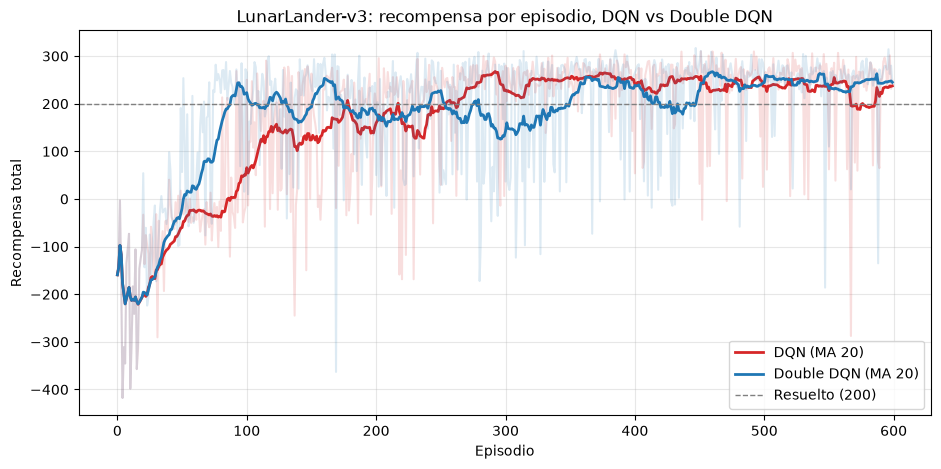

Algoritmo             ep. MA20≥0  ep. MA20≥200  R media total  R últimos 50  máx MA20
DQN                           87           179          168.1         217.1     267.7
Double DQN                    53            89          179.8         246.1     267.2


In [9]:
COLORS = {"DQN": "tab:red", "Double DQN": "tab:blue", "Double DQN + PER": "tab:green"}


def moving_average(x, w=20):
    x = np.asarray(x, dtype=float)
    return np.array([np.nanmean(x[max(0, i - w + 1): i + 1]) for i in range(len(x))])


def first_episode_reaching(x, threshold, w=20):
    ma = moving_average(x, w)
    hits = np.where(ma >= threshold)[0]
    return int(hits[0]) + 1 if len(hits) else None


def summary_table(names):
    print(f"{'Algoritmo':<20}{'ep. MA20≥0':>12}{'ep. MA20≥200':>14}{'R media total':>15}"
          f"{'R últimos 50':>14}{'máx MA20':>10}")
    for name in names:
        r = results[name]["reward"]
        print(f"{name:<20}{str(first_episode_reaching(r, 0)):>12}{str(first_episode_reaching(r, 200)):>14}"
              f"{np.mean(r):>15.1f}{np.mean(r[-50:]):>14.1f}{moving_average(r).max():>10.1f}")


def plot_rewards(names, title):
    plt.figure(figsize=(11, 5))
    for name in names:
        r = results[name]["reward"]
        plt.plot(r, color=COLORS[name], alpha=0.15)
        plt.plot(moving_average(r, 20), color=COLORS[name], lw=2, label=f"{name} (MA 20)")
    plt.axhline(200, ls="--", color="gray", lw=1, label="Resuelto (200)")
    plt.xlabel("Episodio")
    plt.ylabel("Recompensa total")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


plot_rewards(["DQN", "Double DQN"], f"{ENV_ID}: recompensa por episodio, DQN vs Double DQN")
summary_table(["DQN", "Double DQN"])

**Respuestas**

Resultados (semilla 42, figura y tabla anteriores; en la sección *Robustez entre semillas* de la 2.2c están los resultados con 3 semillas):

| | ep. MA20 ≥ 200 (semilla 42) | ep. MA20 ≥ 200 (3 semillas) | pasos hasta MA20 ≥ 200 (3 semillas) | R últimos 50 (3 semillas) | desv. estándar de R, ep. 300–600 |
|---|---:|---:|---:|---:|---:|
| DQN | 179 | 204 ± 43 | 136k ± 42k | **240.7 ± 17.2** | 61 – 71 |
| Double DQN | **89** | **122 ± 24** | **69k ± 22k** | 199.5 ± 44.1 | 93 – 125 |

- **¿Cuál converge más rápido?**

Double DQN converge más rápido: con las tres semillas alcanza el umbral de resolución en 122 ± 24 episodios, frente a 204 ± 43 de DQN, y necesita aproximadamente la mitad de los pasos de interacción (69 mil frente a 136 mil). Esta ventaja es consistente, ya que llega antes al umbral en las tres semillas.


- **¿Cuál alcanza mayor recompensa final?**

DQN obtiene una mayor recompensa final promedio, con 240.7 ± 17.2 frente a 199.5 ± 44.1 de Double DQN, y presenta menor variabilidad al final del entrenamiento. Sin embargo, el resultado depende de la semilla: con la semilla 42, Double DQN termina con una recompensa superior. Ambos alcanzan una MA20 máxima cercana a 267.


- **¿Coincide con lo esperado teóricamente?**

 Solo en parte. La convergencia más rápida de Double DQN es compatible con su capacidad para reducir la sobreestimación de los valores Q, pero no se observa una mayor estabilidad final, pues DQN termina con menos variabilidad. Con solo tres semillas, la diferencia en recompensa final no es concluyente, aunque la ventaja en velocidad de Double DQN sí es consistente en estos experimentos.


### b.

Grafiquen el **valor Q promedio estimado durante el entrenamiento** para ambos algoritmos.

El valor Q de DQN debería ser sistemáticamente mayor que el de Double DQN sobre los mismos estados.

Respondan:

- ¿Observan ese patrón?
- Si no lo observan, argumenten por qué podría no ser visible en este entorno específico.

C:\Users\fagui\AppData\Local\Temp\ipykernel_32656\374268407.py:6: RuntimeWarning: Mean of empty slice
  return np.array([np.nanmean(x[max(0, i - w + 1): i + 1]) for i in range(len(x))])


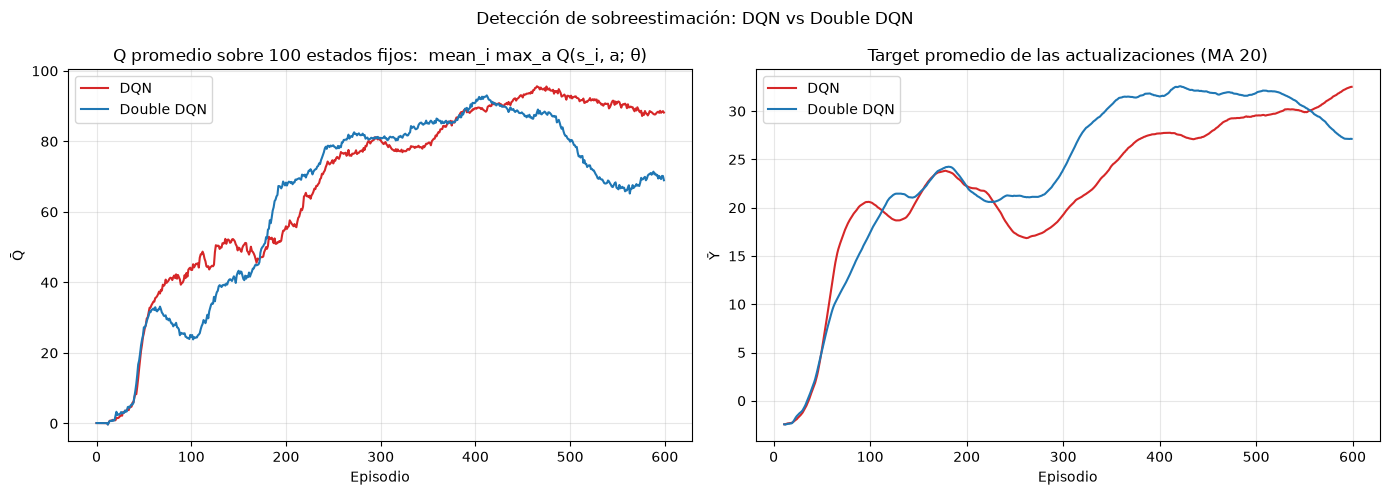

Q̄ medio (todo el entrenamiento)  DQN:   67.57 | Double DQN:   63.26
Q̄ medio (segunda mitad)           DQN:   88.06 | Double DQN:   81.12
Diferencia media DQN − DDQN (2ª mitad): 6.94
% de episodios con Q̄_DQN > Q̄_DDQN:     54.7%
Target medio DQN        :   22.79 (2ª mitad:   28.00)
Target medio Double DQN :   24.39 (2ª mitad:   30.67)


In [10]:
def plot_q_and_targets(names, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for name in names:
        h = results[name]
        axes[0].plot(h["q_mean"], color=COLORS[name], lw=1.5, label=name)
        axes[1].plot(moving_average(h["target_mean"], 20), color=COLORS[name], lw=1.5, label=name)
    axes[0].set_title("Q promedio sobre 100 estados fijos:  mean_i max_a Q(s_i, a; θ)")
    axes[1].set_title("Target promedio de las actualizaciones (MA 20)")
    for ax in axes:
        ax.set_xlabel("Episodio")
        ax.grid(alpha=0.3)
        ax.legend()
    axes[0].set_ylabel("Q̄")
    axes[1].set_ylabel("Ȳ")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_q_and_targets(["DQN", "Double DQN"], "Detección de sobreestimación: DQN vs Double DQN")

q_dqn = np.array(results["DQN"]["q_mean"])
q_ddqn = np.array(results["Double DQN"]["q_mean"])
half = len(q_dqn) // 2
print(f"Q̄ medio (todo el entrenamiento)  DQN: {q_dqn.mean():7.2f} | Double DQN: {q_ddqn.mean():7.2f}")
print(f"Q̄ medio (segunda mitad)           DQN: {q_dqn[half:].mean():7.2f} | Double DQN: {q_ddqn[half:].mean():7.2f}")
print(f"Diferencia media DQN − DDQN (2ª mitad): {(q_dqn[half:] - q_ddqn[half:]).mean():.2f}")
print(f"% de episodios con Q̄_DQN > Q̄_DDQN:     {100 * np.mean(q_dqn > q_ddqn):.1f}%")
for name in ["DQN", "Double DQN"]:
    t = np.array(results[name]["target_mean"], dtype=float)
    print(f"Target medio {name:<11}: {np.nanmean(t):7.2f} (2ª mitad: {np.nanmean(t[half:]):7.2f})")

**Respuestas**

| Semilla | % episodios con $\bar Q_{DQN} > \bar Q_{DDQN}$ | $\bar Q$ medio DQN / DDQN | $\bar Q$ últimos 100 ep. DQN / DDQN |
|---|---:|---:|---:|
| 42 | 54.7% | 67.6 / 63.3 | 90.2 / 70.4 |
| 0 | 23.2% | 55.6 / 66.6 | 84.6 / 80.2 |
| 1 | 77.0% | 68.8 / 62.0 | 103.7 / 83.0 |
| **3 semillas, 2ª mitad** | | **83.0 ± 6.0 / 80.5 ± 3.7** | |

- **¿Se observa el patrón?** 

No se observa de forma constante durante todo el entrenamiento, pero sí al final: en los últimos 100 episodios, DQN presenta valores Q promedio mayores que Double DQN en las tres semillas, con diferencias de +20, +4 y +21. Esto es compatible con la sobreestimación esperada, aunque no la demuestra por sí solo. Los targets promedio no siguen el mismo patrón, ya que cada agente los calcula con experiencias distintas.

- **Por qué no es visible de forma sistemática en LunarLander:**

Las cuatro acciones disponibles y la recompensa densa podrían hacer que el efecto de la sobreestimación sea menos marcado. Además, los agentes aprenden políticas diferentes, por lo que sus valores Q reflejan tanto posibles sesgos como diferencias reales de rendimiento. La variación entre semillas también dificulta distinguir estos efectos con solo tres corridas.

### c.

Implementen ahora **Prioritized Experience Replay (PER)** sobre Double DQN, usando:

- $\alpha = 0.6$
- $\beta$ creciente de $0.4$ a $1.0$

Comparen la velocidad de convergencia de:

- Double DQN con muestreo uniforme.
- Double DQN con PER.

¿En qué fase del entrenamiento es más visible la diferencia?

#### Prioritized Experience Replay (Schaul et al., 2016)

- **Prioridad** proporcional al error TD: $p_i = |\delta_i| + \epsilon$.
- **Probabilidad de muestreo:** $P(i) = \dfrac{p_i^{\alpha}}{\sum_k p_k^{\alpha}}$, con $\alpha = 0.6$ ($\alpha = 0$ equivale a muestreo uniforme).
- **Corrección por *importance sampling*:** $w_i = \left(\dfrac{1}{N \cdot P(i)}\right)^{\beta} \Big/ \max_j w_j$, con $\beta$ lineal de 0.4 → 1.0 (con $\beta = 1$ la corrección es completa al final, cuando importa que el gradiente sea insesgado).
- Las transiciones nuevas entran con la **prioridad máxima** vista hasta el momento, para garantizar que se muestreen al menos una vez.
- Se usa un **SumTree** para muestrear en $O(\log N)$: cada nodo interno guarda la suma de las prioridades de sus hijos y la raíz contiene $\sum_k p_k^\alpha$. El muestreo es estratificado: se divide $[0, \sum_k p_k^\alpha]$ en 64 segmentos y se toma una muestra en cada uno.

In [11]:
class SumTree:
    """Árbol binario de sumas: hojas = p_i^α, raíz = Σ_k p_k^α. Actualizar y buscar en O(log N)."""

    def __init__(self, capacity):
        self.capacity = capacity
        self.tree = np.zeros(2 * capacity - 1, dtype=np.float64)   # hojas en [capacity-1, 2·capacity-2]

    def update(self, data_idx, value):
        tree_idx = data_idx + self.capacity - 1
        change = value - self.tree[tree_idx]
        self.tree[tree_idx] = value
        while tree_idx != 0:                     # propaga el cambio hasta la raíz
            tree_idx = (tree_idx - 1) // 2
            self.tree[tree_idx] += change

    def find(self, value):
        """Devuelve la hoja i tal que Σ_{k<i} p_k^α ≤ value < Σ_{k≤i} p_k^α."""
        idx = 0
        while idx < self.capacity - 1:
            left = 2 * idx + 1
            if value <= self.tree[left]:
                idx = left
            else:
                value -= self.tree[left]
                idx = left + 1
        return idx - (self.capacity - 1)

    def leaf(self, data_idx):
        return self.tree[data_idx + self.capacity - 1]

    @property
    def total(self):
        return self.tree[0]


class PrioritizedReplayBuffer(ReplayBuffer):
    """Experience Replay con P(i) ∝ p_i^α y pesos de importance sampling w_i = (N·P(i))^(-β)."""

    def __init__(self, capacity, state_dim, alpha=PER_ALPHA):
        super().__init__(capacity, state_dim)
        self.alpha = alpha
        self.tree = SumTree(capacity)
        self.max_priority = 1.0          # prioridad (sin exponente) de las transiciones nuevas

    def push(self, s, a, r, s_next, done):
        pos = self.pos
        super().push(s, a, r, s_next, done)
        self.tree.update(pos, self.max_priority ** self.alpha)   # nueva transición: prioridad máxima

    def sample(self, batch_size, beta=PER_BETA_START):
        total = self.tree.total
        segment = total / batch_size
        idx = np.empty(batch_size, dtype=np.int64)
        for i in range(batch_size):      # muestreo estratificado: una muestra por segmento
            value = random.uniform(segment * i, segment * (i + 1))
            j = self.tree.find(min(value, total - 1e-9))
            idx[i] = min(j, self.size - 1)
        priorities = np.array([self.tree.leaf(j) for j in idx])
        probs = np.maximum(priorities / total, 1e-12)                  # P(i) = p_i^α / Σ p_k^α
        weights = (self.size * probs) ** (-beta)                       # w_i = (N·P(i))^(-β)
        weights /= weights.max()                                       # normalizar por max w
        weights = torch.as_tensor(weights, dtype=torch.float32, device=device)
        return (*self._to_tensors(idx), weights, idx)

    def update_priorities(self, idx, td_errors):
        priorities = np.abs(td_errors) + PER_EPS                       # p_i = |δ_i| + ε
        for j, p in zip(idx, priorities):
            self.tree.update(int(j), p ** self.alpha)
        self.max_priority = max(self.max_priority, float(priorities.max()))

In [12]:
results["Double DQN + PER"] = run_or_load("ddqn_per", algo="ddqn", use_per=True)

Cargando results\ddqn_per.json


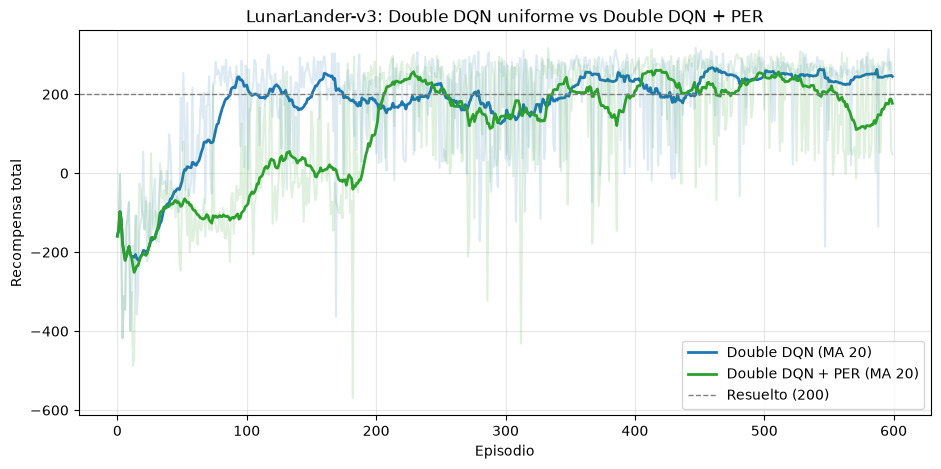

Algoritmo             ep. MA20≥0  ep. MA20≥200  R media total  R últimos 50  máx MA20
DQN                           87           179          168.1         217.1     267.7
Double DQN                    53            89          179.8         246.1     267.2
Double DQN + PER             114           207          117.4         151.3     261.0

Recompensa media por fase:
Algoritmo              inicial     media     final
Double DQN               109.7     192.8     236.7
Double DQN + PER         -41.7     186.3     207.6


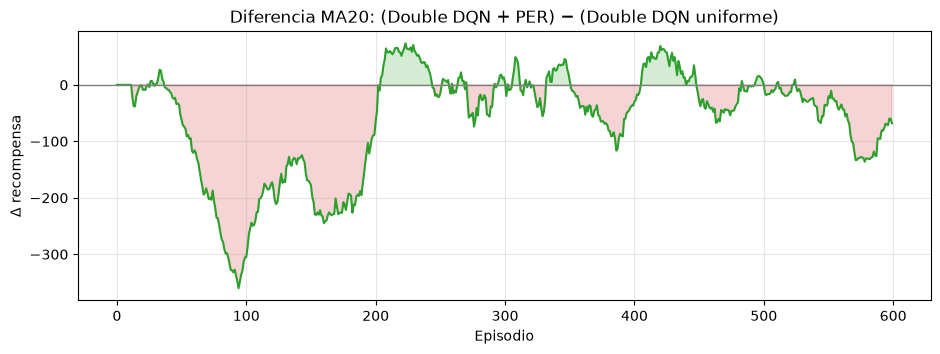

Double DQN           pasos hasta MA20 ≥ 200: 38590
Double DQN + PER     pasos hasta MA20 ≥ 200: 100981


In [13]:
plot_rewards(["Double DQN", "Double DQN + PER"], f"{ENV_ID}: Double DQN uniforme vs Double DQN + PER")
summary_table(["DQN", "Double DQN", "Double DQN + PER"])

# Recompensa media por fase de entrenamiento (tercios)
print("\nRecompensa media por fase:")
print(f"{'Algoritmo':<20}{'inicial':>10}{'media':>10}{'final':>10}")
for name in ["Double DQN", "Double DQN + PER"]:
    r = np.array(results[name]["reward"])
    thirds = np.array_split(r, 3)
    print(f"{name:<20}" + "".join(f"{t.mean():>10.1f}" for t in thirds))

diff = moving_average(results["Double DQN + PER"]["reward"]) - moving_average(results["Double DQN"]["reward"])
plt.figure(figsize=(11, 3.5))
plt.plot(diff, color="tab:green")
plt.axhline(0, color="gray", lw=1)
plt.fill_between(range(len(diff)), diff, 0, where=diff > 0, color="tab:green", alpha=0.2)
plt.fill_between(range(len(diff)), diff, 0, where=diff < 0, color="tab:red", alpha=0.2)
plt.title("Diferencia MA20: (Double DQN + PER) − (Double DQN uniforme)")
plt.xlabel("Episodio")
plt.ylabel("Δ recompensa")
plt.grid(alpha=0.3)
plt.show()

# Pasos de interacción necesarios para alcanzar MA20 ≥ 200 (más justo que episodios, que duran distinto)
for name in ["Double DQN", "Double DQN + PER"]:
    ep = first_episode_reaching(results[name]["reward"], 200)
    steps = results[name]["steps"][ep - 1] if ep else None
    print(f"{name:<20} pasos hasta MA20 ≥ 200: {steps}")

#### Robustez entre semillas

Una sola corrida de RL tiene mucha varianza, así que se repite cada algoritmo con 2 semillas adicionales (0 y 1). Esta tabla se usa como respaldo en las respuestas de a, b, c y d.

Cargando results\dqn_seed0.json
Cargando results\dqn_seed1.json
Cargando results\ddqn_seed0.json
Cargando results\ddqn_seed1.json
Cargando results\ddqn_per_seed0.json
Cargando results\ddqn_per_seed1.json
Algoritmo (3 semillas)      ep. MA20≥0    ep. MA20≥200      pasos MA20≥200    R media total     R últimos 50      Q̄ 2ª mitad
DQN                      126.7 ±  32.3   204.0 ±  42.6      135.9 ±  41.9k    157.4 ±  14.0    240.7 ±  17.2     83.0 ±   6.0
                      semillas que alcanzan MA20≥200: 3/3
Double DQN                96.0 ±  30.9   122.3 ±  24.1       68.9 ±  21.8k    143.5 ±  30.4    199.5 ±  44.1     80.5 ±   3.7
                      semillas que alcanzan MA20≥200: 3/3
Double DQN + PER         100.0 ±   9.9   186.3 ±  29.9       91.8 ±  21.1k    101.0 ±  36.8    181.3 ±  25.3     60.6 ±  14.5
                      semillas que alcanzan MA20≥200: 3/3


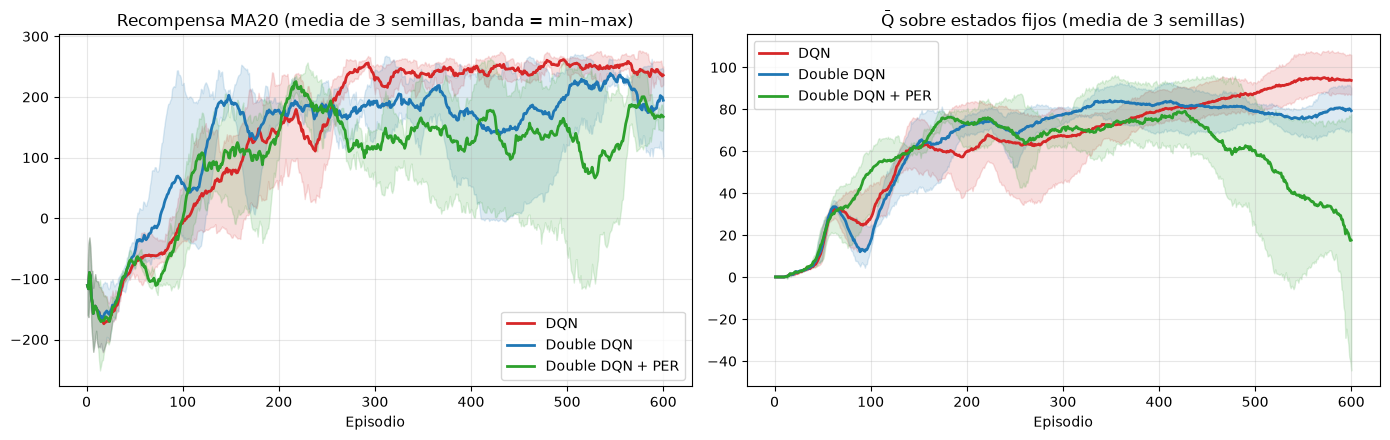

semilla 42: % episodios con Q̄_DQN > Q̄_DDQN =  54.7% | Q̄ medio DQN  67.57 vs DDQN  63.26
semilla  0: % episodios con Q̄_DQN > Q̄_DDQN =  23.2% | Q̄ medio DQN  55.60 vs DDQN  66.62
semilla  1: % episodios con Q̄_DQN > Q̄_DDQN =  77.0% | Q̄ medio DQN  68.81 vs DDQN  61.95


In [14]:
# Robustez: con una sola semilla las diferencias pueden ser ruido, así que se repite cada
# algoritmo con 2 semillas adicionales (0 y 1) y se reporta media ± desviación estándar.
EXTRA_SEEDS = [0, 1]
CONFIGS = {"DQN": dict(algo="dqn"), "Double DQN": dict(algo="ddqn"),
           "Double DQN + PER": dict(algo="ddqn", use_per=True)}
FILE_PREFIX = {"DQN": "dqn", "Double DQN": "ddqn", "Double DQN + PER": "ddqn_per"}

seed_results = {name: [results[name]] for name in CONFIGS}   # semilla 42 = corrida principal
for name, cfg in CONFIGS.items():
    for sd in EXTRA_SEEDS:
        seed_results[name].append(run_or_load(f"{FILE_PREFIX[name]}_seed{sd}", seed=sd, **cfg))


def fmt(values):
    values = [v for v in values if v is not None]
    return f"{np.mean(values):7.1f} ± {np.std(values):5.1f}" if values else "   n/a"


print(f"{'Algoritmo (3 semillas)':<22}{'ep. MA20≥0':>16}{'ep. MA20≥200':>16}{'pasos MA20≥200':>20}"
      f"{'R media total':>17}{'R últimos 50':>17}{'Q̄ 2ª mitad':>17}")
for name, runs in seed_results.items():
    ep0 = [first_episode_reaching(h["reward"], 0) for h in runs]
    ep200 = [first_episode_reaching(h["reward"], 200) for h in runs]
    st200 = [h["steps"][e - 1] / 1000 if e else None for h, e in zip(runs, ep200)]
    print(f"{name:<22}{fmt(ep0):>16}{fmt(ep200):>16}{fmt(st200) + 'k':>20}"
          f"{fmt([np.mean(h['reward']) for h in runs]):>17}"
          f"{fmt([np.mean(h['reward'][-50:]) for h in runs]):>17}"
          f"{fmt([np.mean(h['q_mean'][len(h['q_mean']) // 2:]) for h in runs]):>17}")
    print(f"{'':<22}semillas que alcanzan MA20≥200: {sum(e is not None for e in ep200)}/{len(runs)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for name, runs in seed_results.items():
    ma = np.array([moving_average(h["reward"]) for h in runs])
    q = np.array([h["q_mean"] for h in runs])
    x = np.arange(1, ma.shape[1] + 1)
    for ax, arr in ((axes[0], ma), (axes[1], q)):
        ax.plot(x, arr.mean(0), color=COLORS[name], lw=2, label=name)
        ax.fill_between(x, arr.min(0), arr.max(0), color=COLORS[name], alpha=0.15)
axes[0].set_title("Recompensa MA20 (media de 3 semillas, banda = min–max)")
axes[1].set_title("Q̄ sobre estados fijos (media de 3 semillas)")
for ax in axes:
    ax.set_xlabel("Episodio")
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

# Q̄ DQN vs Double DQN semilla por semilla
for i, sd in enumerate([SEED] + EXTRA_SEEDS):
    qd = np.array(seed_results["DQN"][i]["q_mean"])
    qdd = np.array(seed_results["Double DQN"][i]["q_mean"])
    print(f"semilla {sd:>2}: % episodios con Q̄_DQN > Q̄_DDQN = {100 * np.mean(qd > qdd):5.1f}% | "
          f"Q̄ medio DQN {qd.mean():6.2f} vs DDQN {qdd.mean():6.2f}")

**Respuestas**

| | ep. MA20 ≥ 200 (semilla 42) | pasos (semilla 42) | ep. MA20 ≥ 200 (3 semillas) | pasos (3 semillas) | R media por fase (inicial / media / final, 3 semillas) |
|---|---:|---:|---:|---:|---:|
| Double DQN uniforme | **89** | **38.6k** | **122 ± 24** | **69k ± 22k** | **56.2 / 183.8 / 190.6** |
| Double DQN + PER | 207 | 101.0k | 186 ± 30 | 92k ± 21k | 13.5 / 148.3 / 141.1 |




**¿PER acelera la convergencia?**

En estos experimentos, PER retrasó la convergencia: Double DQN con PER necesitó 186 ± 30 episodios para alcanzar MA20 ≥ 200, frente a 122 ± 24 con muestreo uniforme. También terminó con menor recompensa promedio y mayor variabilidad. Esto podría relacionarse con el muestreo excesivo de transiciones terminales, la corrección parcial del sesgo al inicio y el uso de una tasa de aprendizaje sin ajustar para PER.

**¿En qué fase es más visible la diferencia?**

La diferencia es más visible entre los episodios 50 y 200, cuando la exploración disminuye y el agente depende más de lo aprendido. Con la semilla 42, PER llegó a quedar unos 350 puntos por debajo en MA20 cerca del episodio 100, aunque el comportamiento varió entre semillas. Después del episodio 200, las diferencias se redujeron y cambiaron de signo, pero PER volvió a mostrar inestabilidad al final.

### d.

Argumenten si PER sería **más o menos beneficioso** en el dominio real de detección de intrusiones comparado con LunarLander, considerando la rareza de los eventos críticos que analizaron en la **Task 1.1c**.

Apoyen su argumento con evidencia de sus experimentos.

C:\Users\fagui\AppData\Local\Temp\ipykernel_32656\374268407.py:6: RuntimeWarning: Mean of empty slice
  return np.array([np.nanmean(x[max(0, i - w + 1): i + 1]) for i in range(len(x))])


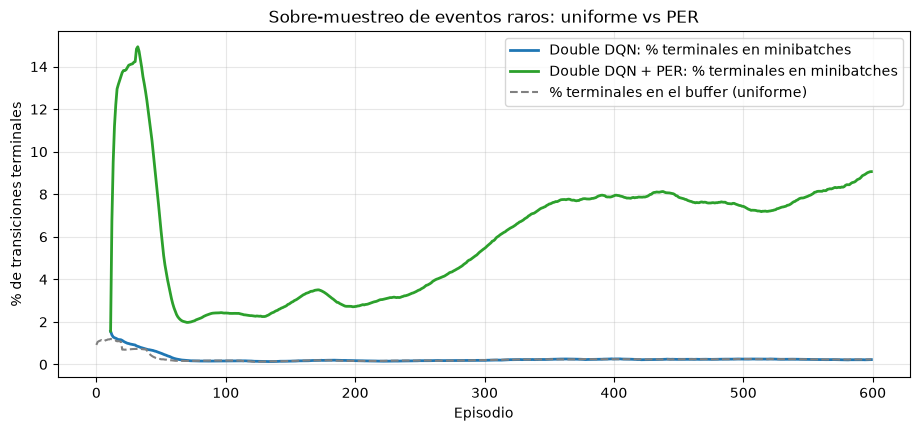

Double DQN           % terminales: buffer  0.26% | muestreado  0.24% | factor × 0.9
Double DQN + PER     % terminales: buffer  0.27% | muestreado  5.98% | factor ×22.2

Con muestreo uniforme y tasa de intrusión 0.1%: P(≥1 intrusión en un minibatch de 64) = 6.2%
Buffer de 50,000 transiciones → ~50 intrusiones almacenadas


In [15]:
# Evidencia: ¿con qué frecuencia se muestrean los "eventos raros"?
# En LunarLander las transiciones terminales (choque -100 / aterrizaje +100) son el análogo
# de una intrusión: ocurren 1 vez por episodio de cientos de pasos y tienen el mayor |δ|.
fig, ax = plt.subplots(figsize=(11, 4.5))
for name in ["Double DQN", "Double DQN + PER"]:
    h = results[name]
    ax.plot(moving_average(h["terminal_frac_sampled"], 20) * 100, color=COLORS[name], lw=2,
            label=f"{name}: % terminales en minibatches")
ax.plot(np.array(results["Double DQN"]["terminal_frac_buffer"]) * 100, color="gray", ls="--",
        label="% terminales en el buffer (uniforme)")
ax.set_xlabel("Episodio")
ax.set_ylabel("% de transiciones terminales")
ax.set_title("Sobre-muestreo de eventos raros: uniforme vs PER")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

for name in ["Double DQN", "Double DQN + PER"]:
    h = results[name]
    s = np.nanmean(h["terminal_frac_sampled"])
    b = np.nanmean(h["terminal_frac_buffer"])
    print(f"{name:<20} % terminales: buffer {100 * b:5.2f}% | muestreado {100 * s:5.2f}% | factor ×{s / b:4.1f}")

rare_rate = 0.001   # < 0.1% de intrusiones (Task 1.1c)
print(f"\nCon muestreo uniforme y tasa de intrusión {rare_rate:.1%}: "
      f"P(≥1 intrusión en un minibatch de {BATCH_SIZE}) = {1 - (1 - rare_rate) ** BATCH_SIZE:.1%}")
print(f"Buffer de {BUFFER_CAPACITY:,} transiciones → ~{int(BUFFER_CAPACITY * rare_rate)} intrusiones almacenadas")

PER podría ser más beneficioso en detección de intrusiones que en LunarLander, porque permitiría aprovechar mejor los eventos poco frecuentes. En nuestros experimentos, aumentó la presencia de transiciones terminales en los minibatches de aproximadamente 0.24% a 6%, unas 22 veces más. En un escenario con 0.1% de intrusiones, solo el 6.2% de los minibatches de 64 muestras incluiría alguna con muestreo uniforme, por lo que priorizarlas podría facilitar su aprendizaje. Sin embargo, este beneficio debe comprobarse: PER también puede amplificar datos ruidosos, favorecer el sobreajuste y aumentar los falsos positivos. Por eso, sería necesario ajustar la tasa de aprendizaje, la intensidad de la priorización y la corrección del sesgo, además de cuidar la calidad de las etiquetas.

---

## Task 2.3

### Investigación bibliográfica y dictamen técnico

### a.

Busquen y lean un paper publicado entre **2022 y 2025** que aplique alguno de los siguientes algoritmos:

- DQN
- Double DQN
- Dueling DQN
- PER
- Rainbow

El paper debe aplicar el algoritmo a un problema de:

- Ciberseguridad.
- Detección de anomalías.
- Gestión de redes.

Debe provenir de una publicación como:

- *IEEE Transactions on Information Forensics and Security*
- NeurIPS
- ICML
- USENIX Security
- O similar.

Escriban un **resumen técnico de media página** que incluya:

1. El problema que resuelve.
2. Qué variante de DQN usa y por qué.
3. Los resultados principales.
4. Una reflexión sobre si las limitaciones de DQN identificadas en la **Task 1** fueron resueltas en ese trabajo.

**Paper:** A. Tellache, A. Mokhtari, A. Amara Korba y Y. Ghamri-Doudane, *"Multi-agent Reinforcement Learning-based Network Intrusion Detection System"*, **IEEE/IFIP Network Operations and Management Symposium (NOMS 2024)**, doi: [10.1109/NOMS59830.2024.10575541]



1. Problema

Los autores proponen un sistema de detección de intrusiones para infraestructura cloud que busca manejar el desbalance de clases y adaptarse a nuevos ataques sin reentrenar todo el modelo. En CIC-IDS-2017 hay millones de flujos benignos, pero apenas unas decenas de ejemplos de ciertos ataques, lo que se parece al escenario de la empresa.

2. Variante y por qué

Utilizan DQN estándar en dos niveles: 14 agentes especializados en distintos ataques y un agente decisor que combina sus valores Q para elegir la clase final. Para dar más importancia a las clases minoritarias, ajustan las recompensas y usan pesos fijos por clase en la función de pérdida, distintos de la priorización dinámica de PER. Esta estructura permite incorporar ataques nuevos actualizando solo parte del sistema.

3. Resultados

El sistema alcanza una exactitud y un F1 ponderado de 0.99, con una tasa de falsos positivos de 0.16%. Además, al incorporar el ataque DoS slowloris, su recall mejora de 0.33 a 0.98 tras un reentrenamiento parcial. Sin embargo, las métricas globales ocultan dificultades con los ataques menos frecuentes, como SQL Injection, cuyo F1 es de apenas 0.03.

4. Reflexión frente a la Task 1

El trabajo respalda el uso de estados vectoriales y acciones discretas, pero resuelve solo parcialmente el problema de los ataques raros. La ponderación por clase no garantiza una buena precisión y el sistema solo clasifica, por lo que no considera los costos ni las consecuencias futuras de bloquear o aislar tráfico. Tampoco aborda explícitamente la sobreestimación de DQN, aunque su descuento de 0.01 reduce mucho el peso de los valores futuros. Finalmente, la evaluación sobre un conjunto estático no permite asegurar el mismo rendimiento en producción.

### b.

Redacten un **dictamen técnico de un párrafo** dirigido al equipo directivo de la empresa de ciberseguridad.

El dictamen debe argumentar:

- Si recomiendan proceder con DQN o alguna de sus variantes para el sistema de detección de intrusiones.
- Qué variante específica recomiendan y por qué.
- Qué pasos adicionales serían necesarios antes de un despliegue en producción.

El dictamen debe estar respaldado por **evidencia de sus experimentos**, no solo por argumentos teóricos.

Recomendamos avanzar con Double DQN y un método que dé más atención a los ataques poco frecuentes, pero comenzar como apoyo a las decisiones y con supervisión humana. En las pruebas, esta opción aprendió más rápido y necesitó cerca de la mitad de las interacciones que DQN estándar, que mostró una tendencia a sobrevalorar sus decisiones y podría provocar bloqueos o aislamientos innecesarios. Sin embargo, dar prioridad a los ataques raros requiere ajustes cuidadosos, porque una mala configuración puede volver el aprendizaje más lento e inestable. Antes de usarlo en condiciones reales, es necesario entrenarlo con tráfico propio identificado, definir el costo de dejar pasar un ataque o generar una falsa alarma y comparar sus resultados con el sistema actual, especialmente ante ataques poco comunes. También debe probarse sin ejecutar acciones automáticamente, mantener la aprobación humana para bloquear o aislar y revisarse periódicamente para adaptarse a los cambios del tráfico y a nuevas amenazas.